<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=294535214" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, preprocessing
from joblib import Parallel, delayed

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.], device='cuda:0') cuda


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.05
1,A,NYSE - Delayed Quote,2010-03-01,22.50
2,A,NYSE - Delayed Quote,2010-04-01,24.60
3,A,NYSE - Delayed Quote,2010-05-01,25.94
4,A,NYSE - Delayed Quote,2010-06-01,23.15
...,...,...,...,...
604455,ZYME,NasdaqGS - Delayed Quote,2025-09-01,14.81
604456,ZYME,NasdaqGS - Delayed Quote,2025-10-01,17.08
604457,ZYME,NasdaqGS - Delayed Quote,2025-11-01,19.08
604458,ZYME,NasdaqGS - Delayed Quote,2025-12-01,26.71


In [6]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090001,2026-01-24,0002082542,2025-09-30,0.000225,NaN,NaN,NaN,-0.000017,-0.000027,0.000064,...,NaN,NaN,NaN,NaN,NaN,BIXI,NASDAQ,NaN,NaN,116
1090002,2026-01-24,0002082844,2025-09-30,0.000197,NaN,NaN,NaN,-0.000034,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,SAC-U,NYSE,NaN,NaN,116
1090003,2026-01-24,0002084563,2025-09-30,0.000295,NaN,NaN,NaN,-0.000036,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,LFAC,NASDAQ,NaN,NaN,116
1090004,2026-01-24,0002088749,2025-09-30,0.000676,NaN,NaN,NaN,-0.000032,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,KBON,NASDAQ,NaN,NaN,116


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [7]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)
snapshots

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30    AIR   1.821612     0.957664   
           0000001800 2011-09-30    ABT  59.628176    35.024376   
           0000002098 2011-09-30    ACU   0.055344     0.027783   
           0000002488 2011-10-01    AMD   5.236000     3.492000   
           0000002969 2011-09-30    APD  14.290700     8.494900   
...                                 ...        ...          ...   
2026-01-24 0001905956 2025-09-30    TGL   0.016595     0.004622   
           0001906324 2025-09-28   QDEL   5.675100     3.638700   
           0001907982 2025-09-30   QBTS   0.865820     0.195266   
           0001914605 2025-09-30   ECBK   1.552653     1.383344   
           0001915657 2025-09-30   DINO  17.264000     7.834000   

                                  NetCashOperating_ttm  price  
snapshot   cik        date                                     
2012-01-01 0000001750 2011-11-30              0.083588  19.17  
           0000001800 2011-09-30              9.885247  26.98  
           0000002098 2011-09-30             -0.003533   9.50  
           0000002488 2011-10-01             -0.018000   5.40  
           0000002969 2011-09-30              1.753200  78.81  
...                                                ...    ...  
2026-01-24 0001905956 2025-09-30             -0.010266    NaN  
           0001906324 2025-09-28              0.037000    NaN  
           0001907982 2025-09-30             -0.051593    NaN  
           0001914605 2025-09-30              0.009768    NaN  
           0001915657 2025-09-30              1.167000    NaN  

[456837 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [8]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 169 unique snapshots and 3399 unique ciks for a total of 574431 records.


Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-09-01       False  
           2025-10-01       False  
           2025-11-01       False  
           2025-12-01       False  
           2026-01-01       False  

[574431 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [9]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=1, keepdim=True),
                                  x2 - x2.mean(dim=1, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [10]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3399, 169, 3])
Labels shape: torch.Size([3399, 169])
Asset multiplier shape: torch.Size([3399])
Cash multiplier shape: torch.Size([169])


device(type='cuda', index=0)

Adjusted assets shape: torch.Size([3399, 169])
Adjusted cashflow shape: torch.Size([3399, 169])
Forward shape: torch.Size([3399, 169])
Epoch [1000/10000], Loss=999.09339339
Epoch [2000/10000], Loss=998.45570146
Epoch [3000/10000], Loss=997.80033531
Epoch [4000/10000], Loss=997.59157022
Epoch [5000/10000], Loss=997.42585007
Epoch [6000/10000], Loss=997.55065878
Epoch [7000/10000], Loss=997.45118120
Epoch [8000/10000], Loss=997.35603821
Epoch [9000/10000], Loss=997.40096508
Epoch [10000/10000], Loss=997.32512281


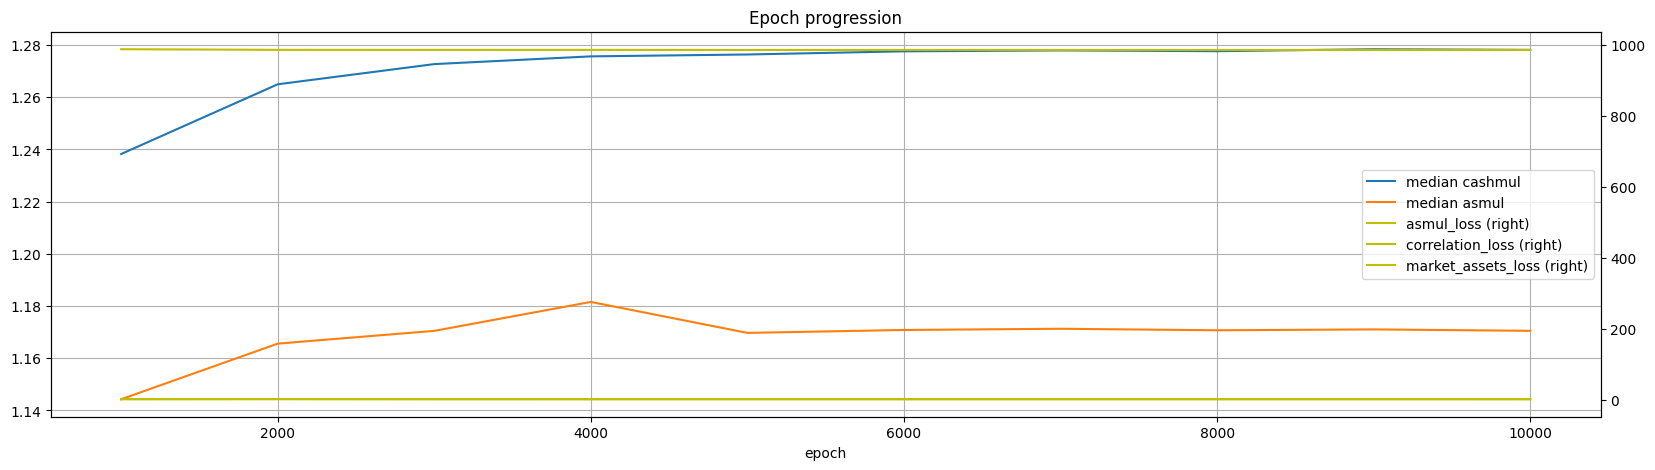

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.238250,1.144285,0.941386,988.663815,1.015719
2000,1.264963,1.165590,1.018533,986.879660,1.390712
3000,1.272698,1.170478,1.015117,986.742504,0.906658
4000,1.275658,1.181565,0.986301,986.818953,0.909611
5000,1.276379,1.169702,0.987481,986.636818,0.914226
6000,1.277596,1.170821,0.997197,986.673528,0.905164
7000,1.277943,1.171282,0.986977,986.683796,0.897615
8000,1.277651,1.170705,0.991279,986.573492,0.869753
9000,1.278398,1.171035,0.986248,986.645662,0.892825


In [11]:
def model_train(model, num_epochs = 10000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [12]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2012-01-01  0.999799 -1.141094  0.768201  
           2012-02-01  0.999799 -1.007566  0.779362  
           2012-03-01  0.999799 -0.933211  0.785578  
           2012-04-01  0.999799 -0.862020  0.831967  
           2012-05-01  0.999799 -0.888194  0.830216  
...                         ...       ...       ...  
0001915657 2025-09-01  0.834058  1.568261  8.160379  
           2025-10-01  0.834058  1.561579  8.153248  
           2025-11-01  0.834058  1.449647  8.256921  
           2025-12-01  0.834058  1.483345  8.296245  
           2026-01-01  0.834058  1.489826  8.303809  

[438464 rows x 7 columns]

In [13]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(a_group):
    (ticker, cik), df = a_group
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    df['slope'] = regressor.coef_[0]
    df['intercept'] = regressor.intercept_
    return df

with Parallel(n_jobs=-1) as p:
    result = pd.concat(p(delayed(line_fit)(i) for i in result.groupby(by=['ticker','cik'])))
    
result = result.reset_index().set_index(['snapshot','cik','date']).sort_index()

# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept
snapshot,cik,date,,,,,,,,,,
2024-07-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,193.25,0.595283,1.271481,204.087626,0.577235,45.502074
2024-08-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,186.98,0.595283,1.517715,243.268459,0.577235,45.502074
2024-09-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,178.50,0.595283,1.542434,285.052145,0.577235,45.502074
2024-10-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.33,0.595283,1.576361,291.060292,0.577235,45.502074
2024-11-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.40,0.595283,1.499722,277.488261,0.577235,45.502074
2024-12-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,207.89,0.595283,1.758587,363.608919,0.577235,45.502074
2025-01-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,219.39,0.595283,1.498696,313.204947,0.577235,45.502074
2025-02-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,237.68,0.595283,1.578030,328.591136,0.577235,45.502074
2025-03-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,212.28,0.595283,1.500137,328.763107,0.577235,45.502074


Let's examine the achieved correlations using a histogram:

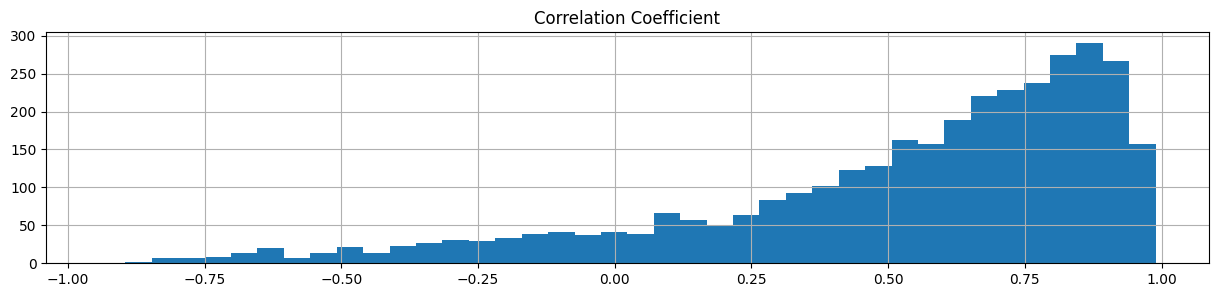

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']]
model_corr = model_corr.rename(columns={'model':'Correlation Coefficient'}).set_index('cik')
model_corr.hist(figsize=(15,3),bins=40)
plt.show()

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

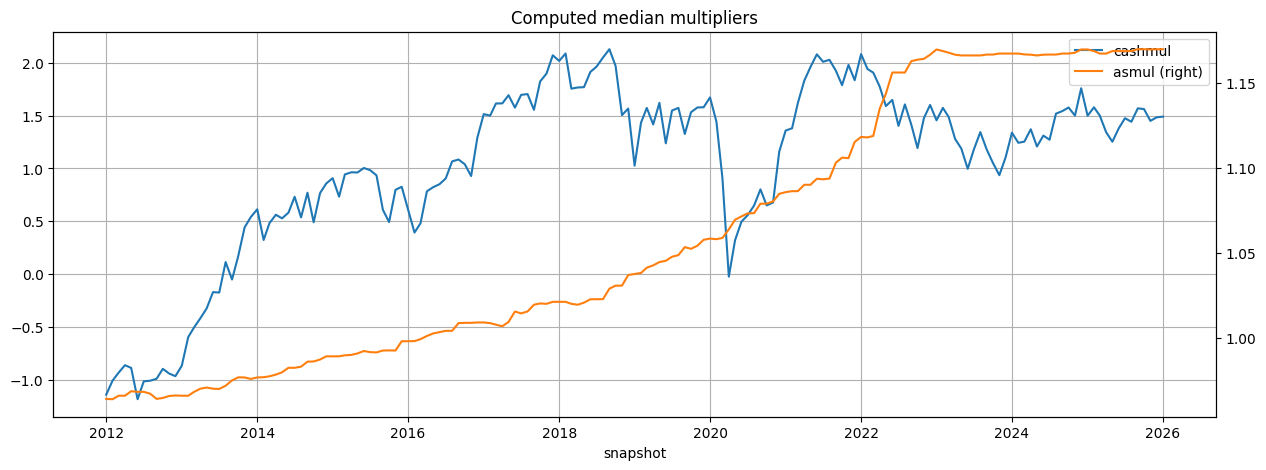

Median asset_multiplier per cik: 1.1704968214035034
Median asset_multiplier per snapshot: 1.0377249717712402


In [15]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [16]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

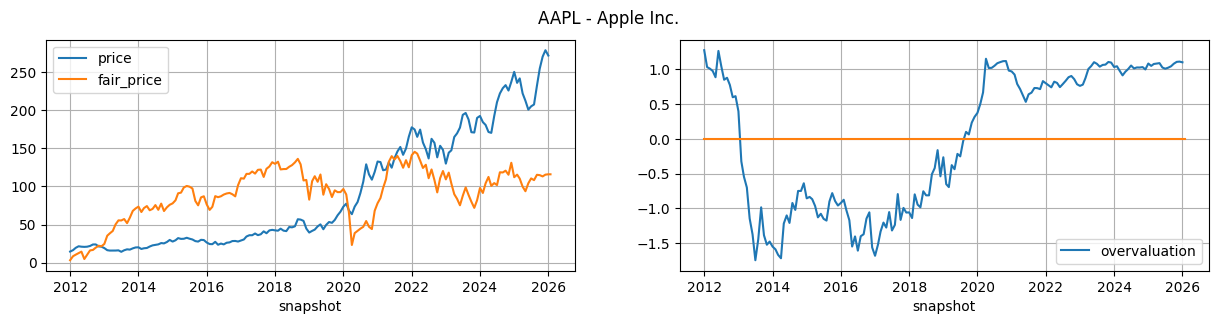

AAPL fair_price = 0.617482 * (0.904051 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -10.875731


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320193,2025-06-28,AAPL,331.495,265.665,108.565,0.904051,1.561579,0.617482,-10.875731,203.556317,114.816571
2025-11-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.904051,1.449647,0.617482,-10.875731,200.873910,113.160234
2025-12-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.904051,1.483345,0.617482,-10.875731,204.630547,115.479889
2026-01-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.904051,1.489826,0.617482,-10.875731,205.353054,115.926024
2026-01-24,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.904051,1.489826,0.617482,-10.875731,205.353054,115.926024


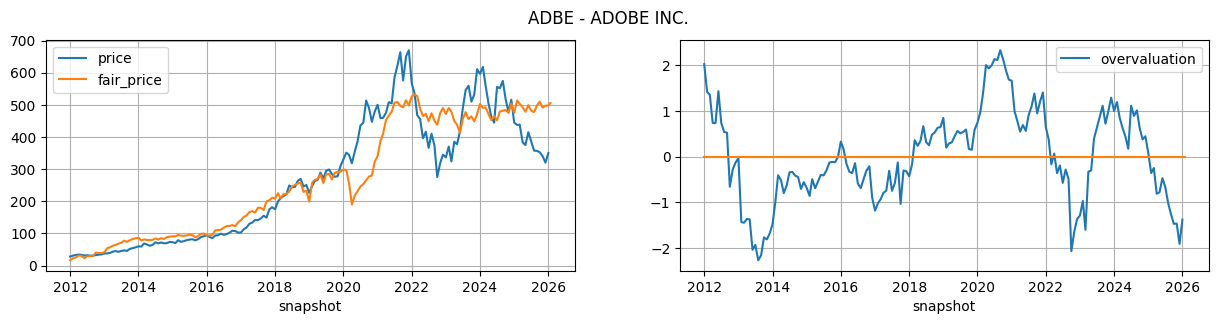

ADBE fair_price = 16.765485 * (1.314549 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -95.379553


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.314549,1.561579,16.765485,-95.379553,36.105518,509.946959
2025-11-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.314549,1.449647,16.765485,-95.379553,35.009485,491.571440
2025-12-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.314549,1.483345,16.765485,-95.379553,35.339449,497.103437
2026-01-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.314549,1.489826,16.765485,-95.379553,35.402910,498.167396
2026-01-24,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,1.314549,1.489826,16.765485,-95.379553,35.845374,505.585513


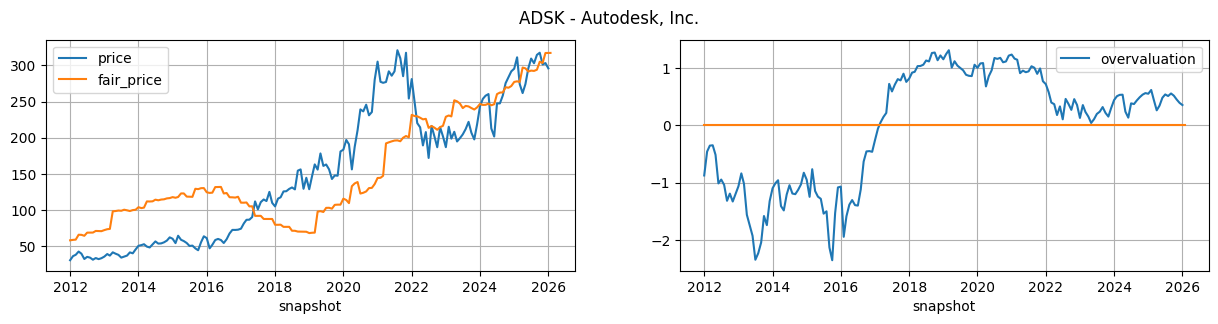

ADSK fair_price = 7.868087 * (4.423378 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -32.254646


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.423378,1.561579,7.868087,-32.254646,42.885226,305.170035
2025-11-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.423378,1.449647,7.868087,-32.254646,42.669758,303.474714
2025-12-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.423378,1.483345,7.868087,-32.254646,44.424589,317.281882
2026-01-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.423378,1.489826,7.868087,-32.254646,44.438556,317.391771
2026-01-24,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.423378,1.489826,7.868087,-32.254646,44.438556,317.391771


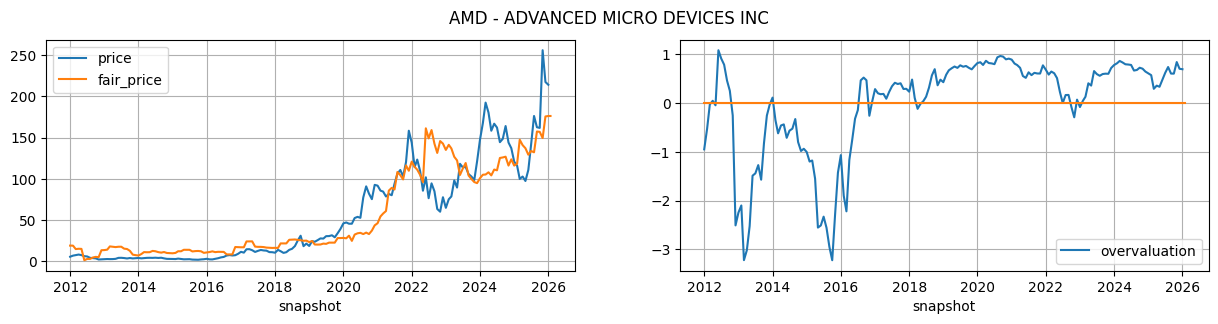

AMD fair_price = 13.721333 * (0.203086 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +51.928542


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.203086,1.561579,13.721333,51.928542,7.655748,156.975616
2025-11-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.203086,1.449647,13.721333,51.928542,7.109859,149.485282
2025-12-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.203086,1.483345,13.721333,51.928542,9.019793,175.692125
2026-01-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.203086,1.489826,13.721333,51.928542,9.061323,176.261970
2026-01-24,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.203086,1.489826,13.721333,51.928542,9.061323,176.261970


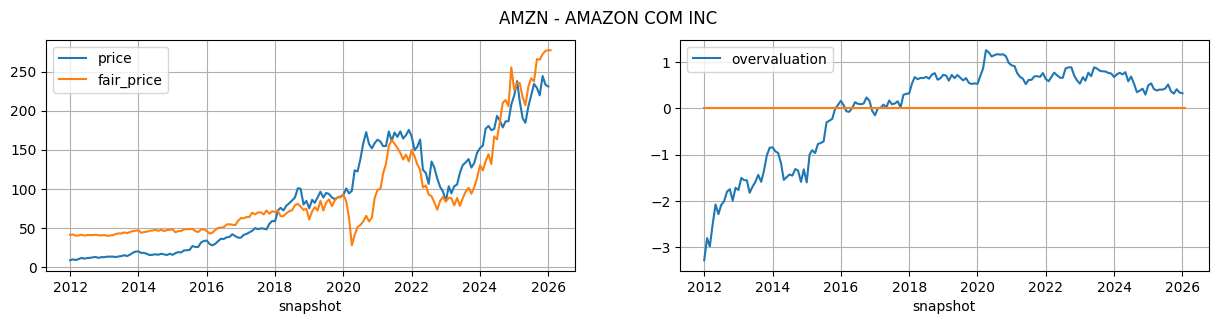

AMZN fair_price = 0.577235 * (0.595283 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.502074


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001018724,2025-06-30,AMZN,682.170,348.395,206.735833,0.595283,1.561579,0.577235,45.502074,380.523331,265.153604
2025-11-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.595283,1.449647,0.577235,45.502074,392.646796,272.151697
2025-12-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.595283,1.483345,0.577235,45.502074,400.029868,276.413468
2026-01-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.595283,1.489826,0.577235,45.502074,401.449842,277.233127
2026-01-24,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.595283,1.489826,0.577235,45.502074,401.449842,277.233127


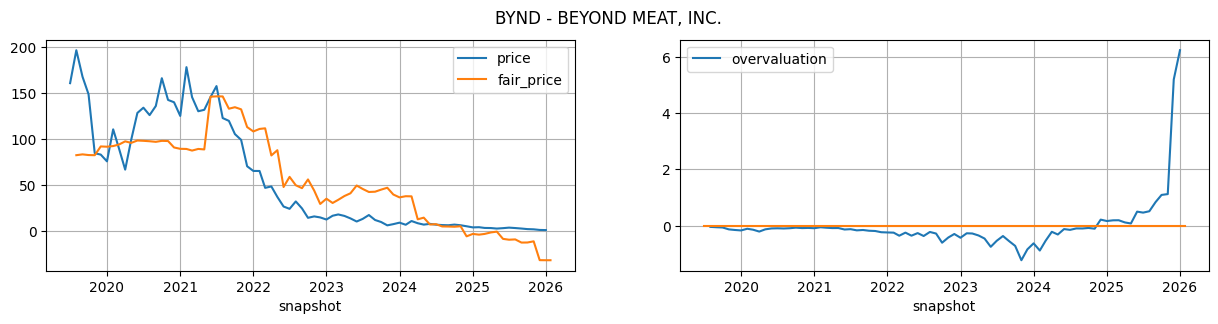

BYND fair_price = 102.892638 * (1.688212 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.726575


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.688212,1.561579,102.892638,25.726575,-0.373285,-12.681737
2025-11-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.688212,1.449647,102.892638,25.726575,-0.360933,-11.410798
2025-12-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.688212,1.483345,102.892638,25.726575,-0.559884,-31.881381
2026-01-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.688212,1.489826,102.892638,25.726575,-0.560708,-31.966130
2026-01-24,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.688212,1.489826,102.892638,25.726575,-0.560708,-31.966130


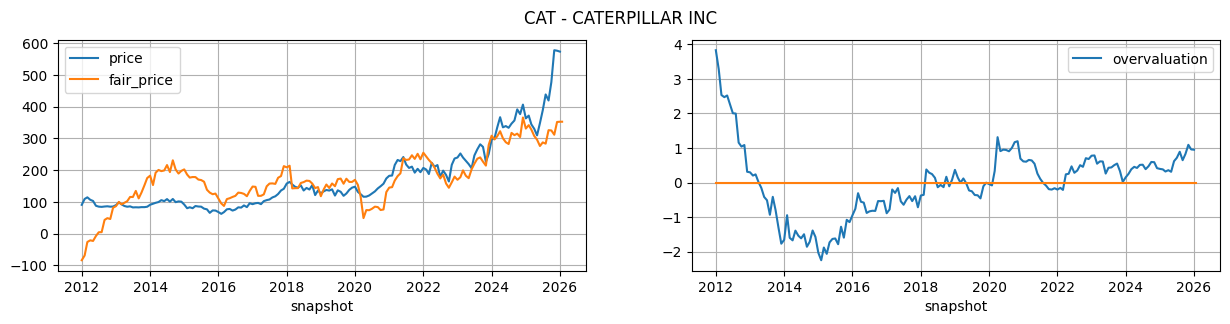

CAT fair_price = 10.615847 * (1.339361 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -387.286167


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.339361,1.561579,10.615847,-387.286167,67.075593,324.778042
2025-11-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.339361,1.449647,10.615847,-387.286167,65.802597,311.264108
2025-12-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.339361,1.483345,10.615847,-387.286167,69.583846,351.405268
2026-01-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.339361,1.489826,10.615847,-387.286167,69.658642,352.199295
2026-01-24,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.339361,1.489826,10.615847,-387.286167,69.658642,352.199295


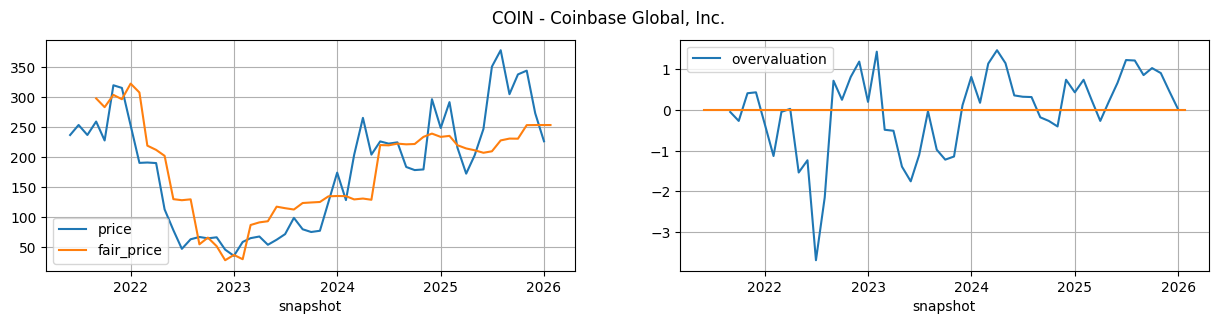

COIN fair_price = 13.288230 * (1.015108 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.526167


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,1.015108,1.561579,13.28823,27.526167,15.271198,230.453364
2025-11-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015108,1.449647,13.28823,27.526167,16.969251,253.017483
2025-12-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015108,1.483345,13.28823,27.526167,16.980232,253.163391
2026-01-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015108,1.489826,13.28823,27.526167,16.982344,253.191453
2026-01-24,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015108,1.489826,13.28823,27.526167,16.982344,253.191453


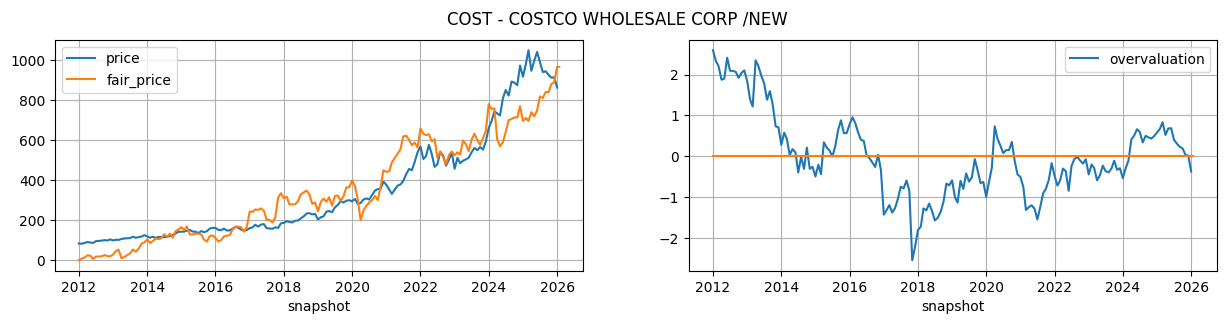

COST fair_price = 19.402395 * (1.105788 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -219.094189


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000909832,2025-05-11,COST,75.482,48.357,12.426,1.105788,1.561579,19.402395,-219.094189,54.514259,838.612998
2025-11-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.105788,1.449647,19.402395,-219.094189,56.651188,880.074526
2025-12-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.105788,1.483345,19.402395,-219.094189,57.100540,888.793047
2026-01-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.105788,1.489826,19.402395,-219.094189,61.055473,965.528218
2026-01-24,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.105788,1.489826,19.402395,-219.094189,61.055473,965.528218


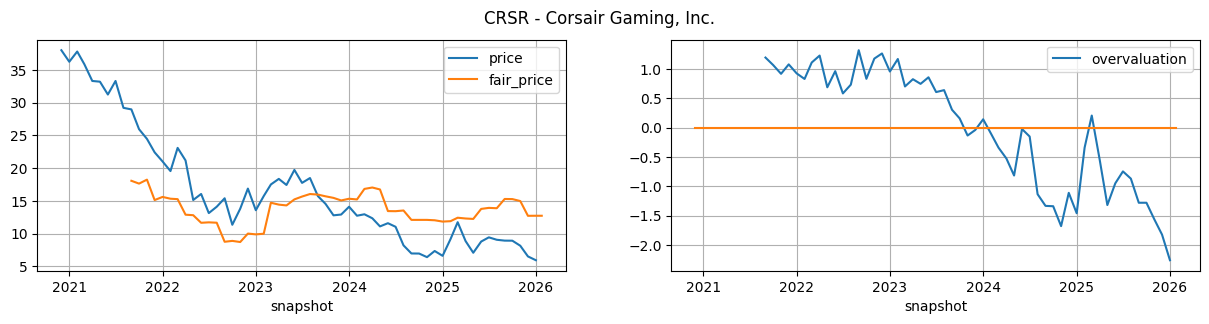

CRSR fair_price = 20.656364 * (1.752858 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -20.389054


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.752858,1.561579,20.656364,-20.389054,1.726178,15.267507
2025-11-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.752858,1.449647,20.656364,-20.389054,1.711672,14.967862
2025-12-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.752858,1.483345,20.656364,-20.389054,1.602665,12.716189
2026-01-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.752858,1.489826,20.656364,-20.389054,1.603103,12.725226
2026-01-24,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.752858,1.489826,20.656364,-20.389054,1.603103,12.725226


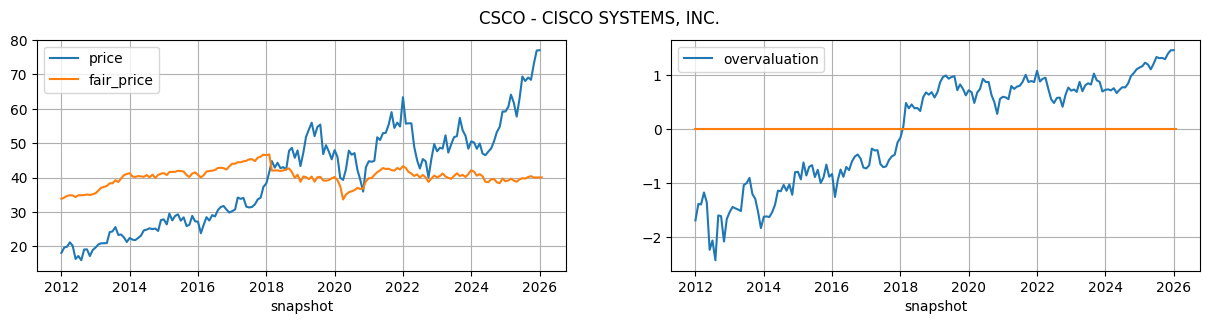

CSCO fair_price = 0.261999 * (0.749512 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +30.350932


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.749512,1.561579,0.261999,30.350932,38.374056,40.404887
2025-11-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.749512,1.449647,0.261999,30.350932,36.785413,39.988664
2025-12-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.749512,1.483345,0.261999,30.350932,36.925486,40.025363
2026-01-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.749512,1.489826,0.261999,30.350932,37.014560,40.048701
2026-01-24,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.749512,1.489826,0.261999,30.350932,37.014560,40.048701


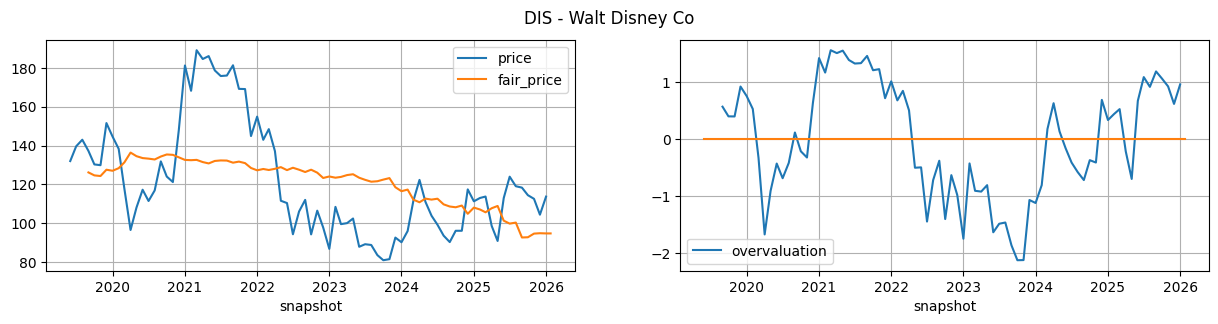

DIS fair_price = -0.877020 * (0.950254 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +206.220787


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.950254,1.561579,-0.87702,206.220787,129.260842,92.856380
2025-11-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.950254,1.449647,-0.87702,206.220787,127.117914,94.735771
2025-12-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.950254,1.483345,-0.87702,206.220787,126.893566,94.932529
2026-01-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.950254,1.489826,-0.87702,206.220787,127.010877,94.829645
2026-01-24,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.950254,1.489826,-0.87702,206.220787,127.010877,94.829645


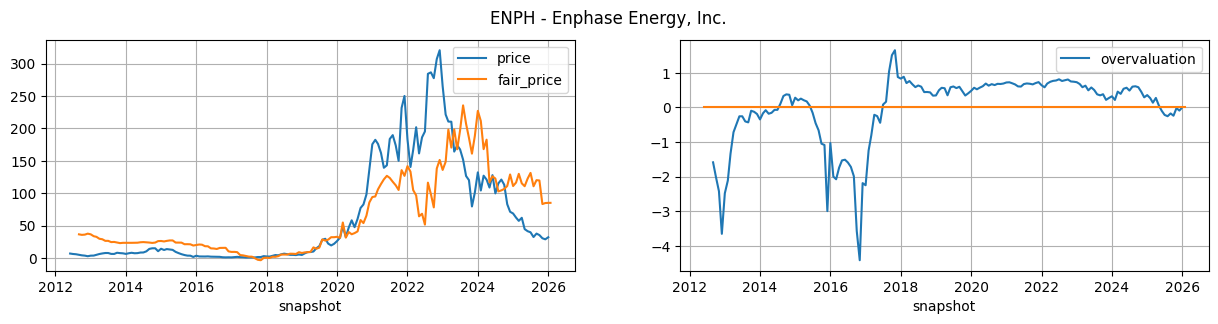

ENPH fair_price = 179.795536 * (0.689410 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +22.992540


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.68941,1.561579,179.795536,22.99254,0.537445,119.622821
2025-11-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.68941,1.449647,179.795536,22.99254,0.335187,83.257746
2025-12-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.68941,1.483345,179.795536,22.99254,0.343822,84.810284
2026-01-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.68941,1.489826,179.795536,22.99254,0.345483,85.108881
2026-01-24,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.68941,1.489826,179.795536,22.99254,0.345483,85.108881


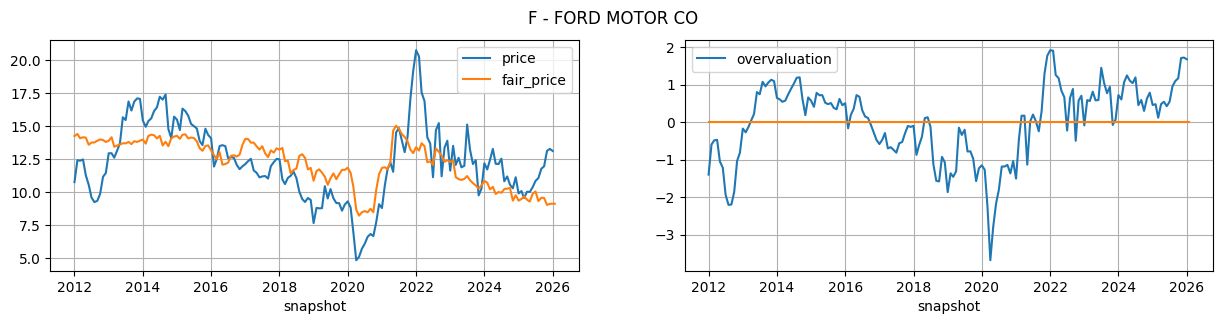

F fair_price = 0.106851 * (0.039667 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +31.687655


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000037996,2025-06-30,F,292.725,247.668,18.526,0.039667,1.561579,0.106851,31.687655,-207.126682,9.555944
2025-11-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.039667,1.449647,0.106851,31.687655,-212.048146,9.030081
2025-12-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.039667,1.483345,0.106851,31.687655,-211.359846,9.103626
2026-01-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.039667,1.489826,0.106851,31.687655,-211.227467,9.117771
2026-01-24,0000037996,2025-09-30,F,300.990,253.598,20.426,0.039667,1.489826,0.106851,31.687655,-211.227467,9.117771


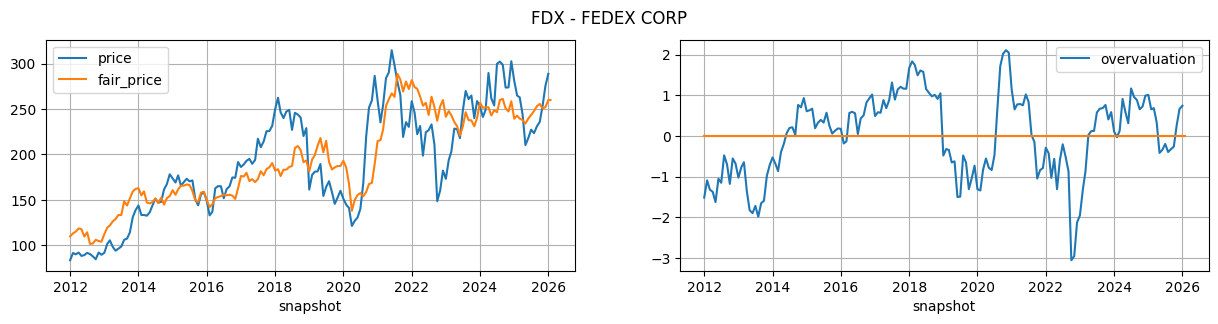

FDX fair_price = 5.998206 * (0.931164 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +54.763334


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.931164,1.561579,5.998206,54.763334,33.498106,255.691879
2025-11-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.931164,1.449647,5.998206,54.763334,32.651344,250.612830
2025-12-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.931164,1.483345,5.998206,54.763334,32.906264,252.141891
2026-01-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.931164,1.489826,5.998206,54.763334,34.214692,259.990112
2026-01-24,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.931164,1.489826,5.998206,54.763334,34.214692,259.990112


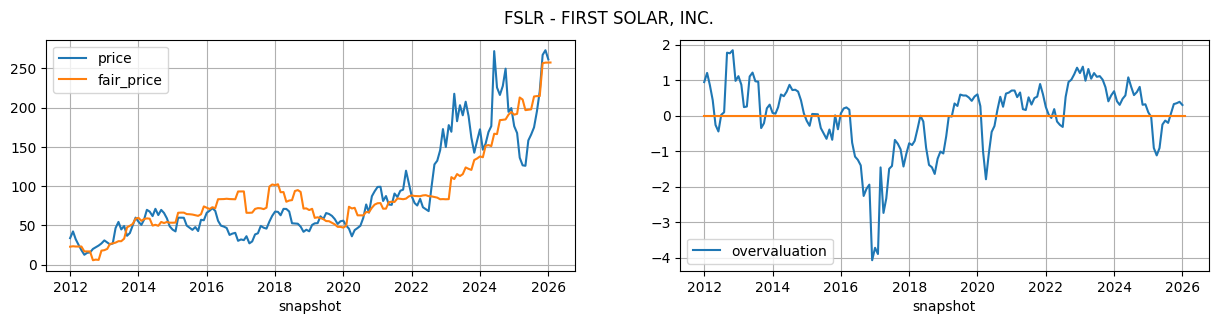

FSLR fair_price = 13.432536 * (2.259108 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -124.008580


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,2.259107,1.561579,13.432536,-124.00858,25.202473,214.524542
2025-11-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.259107,1.449647,13.432536,-124.00858,28.319452,256.393467
2025-12-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.259107,1.483345,13.432536,-124.00858,28.374251,257.129553
2026-01-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.259107,1.489826,13.432536,-124.00858,28.384790,257.271123
2026-01-24,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.259107,1.489826,13.432536,-124.00858,28.384790,257.271123


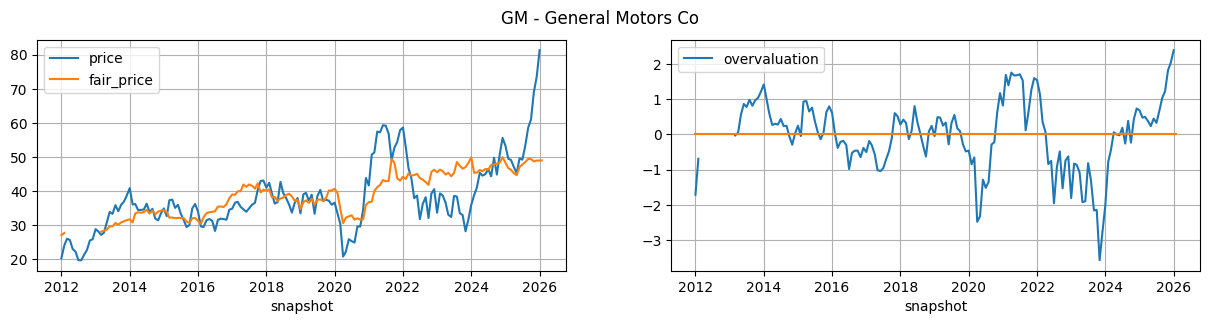

GM fair_price = 0.311113 * (0.968443 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +19.946209


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001467858,2025-06-30,GM,289.384,223.021,23.970,0.968443,1.561579,0.311113,19.946209,94.661896,49.396791
2025-11-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.968443,1.449647,0.311113,19.946209,92.379088,48.686579
2025-12-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.968443,1.483345,0.311113,19.946209,93.194965,48.940410
2026-01-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.968443,1.489826,0.311113,19.946209,93.351882,48.989228
2026-01-24,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.968443,1.489826,0.311113,19.946209,93.351882,48.989228


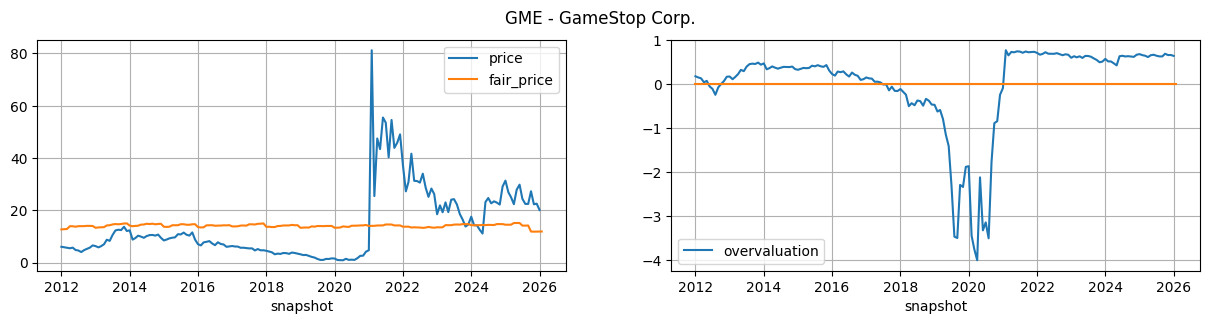

GME fair_price = 0.895236 * (0.000158 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +15.790346


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000158,1.561579,0.895236,15.790346,-4.387270,11.862705
2025-11-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000158,1.449647,0.895236,15.790346,-4.442878,11.812923
2025-12-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000158,1.483345,0.895236,15.790346,-4.426137,11.827910
2026-01-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000158,1.489826,0.895236,15.790346,-4.376716,11.872153
2026-01-24,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000158,1.489826,0.895236,15.790346,-4.376716,11.872153


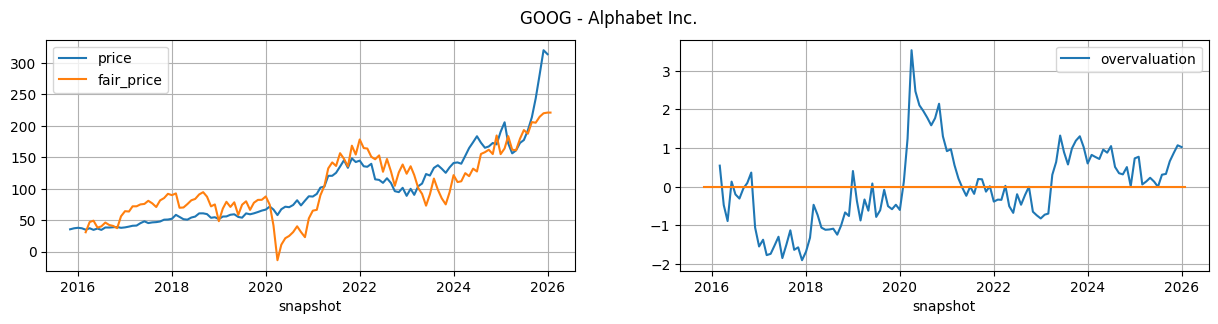

GOOG fair_price = 1.086500 * (0.246126 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -5.020271


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001652044,2025-06-30,GOOG,502.053,139.137,133.708,0.246126,1.561579,1.0865,-5.020271,193.227092,204.921025
2025-11-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.246126,1.449647,1.0865,-5.020271,201.948603,214.396949
2025-12-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.246126,1.483345,1.0865,-5.020271,207.051175,219.940895
2026-01-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.246126,1.489826,1.0865,-5.020271,208.032543,221.007153
2026-01-24,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.246126,1.489826,1.0865,-5.020271,208.032543,221.007153


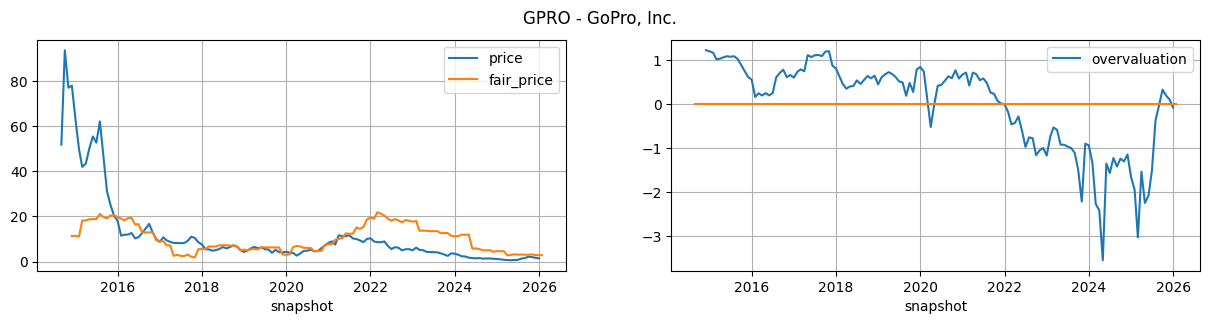

GPRO fair_price = 20.427538 * (0.816583 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +5.063264


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.816583,1.561579,20.427538,5.063264,-0.100935,3.001412
2025-11-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.816583,1.449647,20.427538,5.063264,-0.092453,3.174675
2025-12-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.816583,1.483345,20.427538,5.063264,-0.109330,2.829919
2026-01-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.816583,1.489826,20.427538,5.063264,-0.109728,2.821794
2026-01-24,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.816583,1.489826,20.427538,5.063264,-0.109728,2.821794


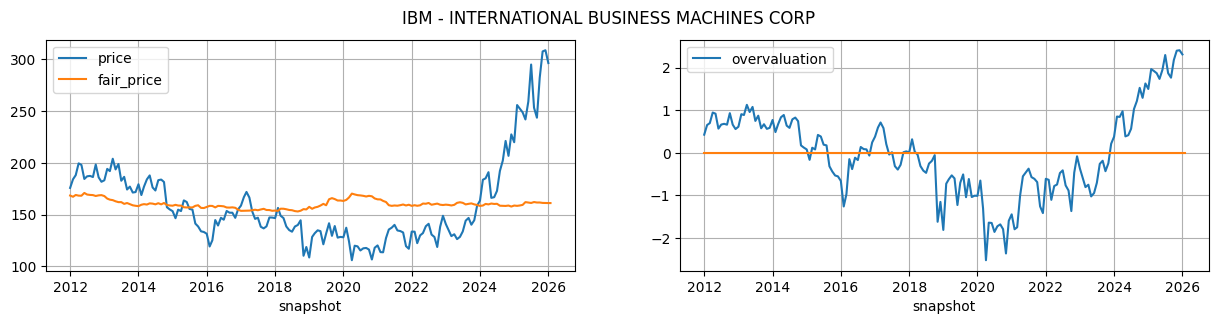

IBM fair_price = -0.273661 * (0.003691 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +134.415229


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000051143,2025-06-30,IBM,148.585,121.076,13.282,0.003691,1.561579,-0.273661,134.415229,-99.786724,161.722969
2025-11-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003691,1.449647,-0.273661,134.415229,-98.321407,161.321969
2025-12-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003691,1.483345,-0.273661,134.415229,-97.867067,161.197634
2026-01-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003691,1.489826,-0.273661,134.415229,-97.779685,161.173721
2026-01-24,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003691,1.489826,-0.273661,134.415229,-97.779685,161.173721


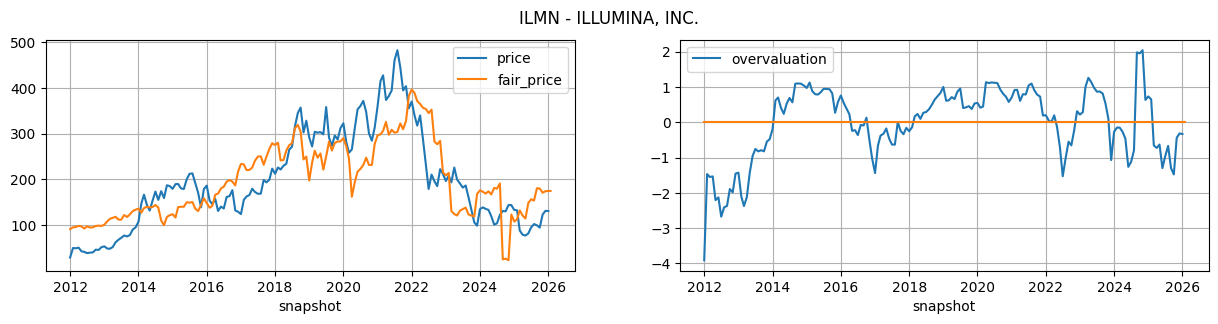

ILMN fair_price = 85.010174 * (0.400482 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +145.307038


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001110803,2025-06-29,ILMN,6.087,3.829,1.154,0.400482,1.561579,85.010174,145.307038,0.410797,180.228965
2025-11-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400482,1.449647,85.010174,145.307038,0.304283,171.174174
2025-12-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400482,1.483345,85.010174,145.307038,0.342091,174.388265
2026-01-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400482,1.489826,85.010174,145.307038,0.349363,175.006425
2026-01-24,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400482,1.489826,85.010174,145.307038,0.349363,175.006425


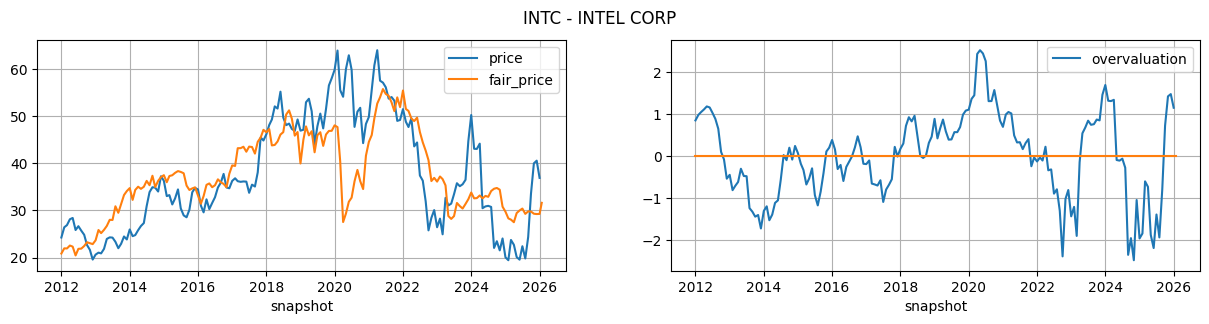

INTC fair_price = 0.414658 * (0.436791 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.610087


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.436791,1.561579,0.414658,27.610087,5.197802,29.765396
2025-11-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.436791,1.449647,0.414658,27.610087,4.069309,29.297458
2025-12-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.436791,1.483345,0.414658,27.610087,3.910030,29.231412
2026-01-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.436791,1.489826,0.414658,27.610087,3.965597,29.254453
2026-01-24,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.436791,1.489826,0.414658,27.610087,9.649080,31.611153


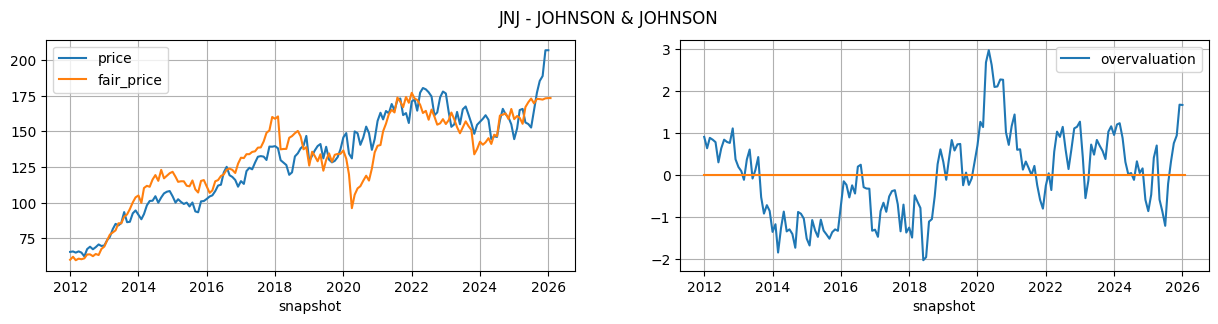

JNJ fair_price = 1.084233 * (1.419550 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -39.358414


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000200406,2025-06-29,JNJ,193.389,114.916,23.028,1.41955,1.561579,1.084233,-39.358414,195.569451,172.684368
2025-11-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.41955,1.449647,1.084233,-39.358414,195.260277,172.349151
2025-12-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.41955,1.483345,1.084233,-39.358414,196.075885,173.233460
2026-01-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.41955,1.489826,1.084233,-39.358414,196.232750,173.403537
2026-01-24,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.41955,1.489826,1.084233,-39.358414,196.232750,173.403537


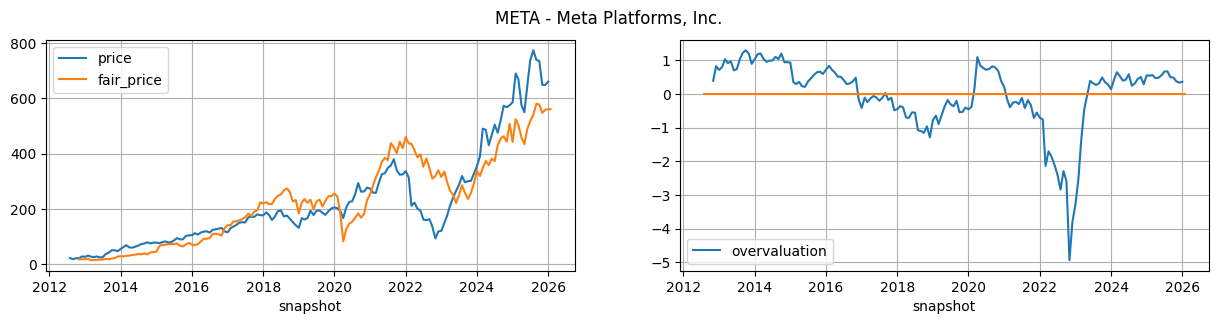

META fair_price = 3.036274 * (0.432571 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +7.827291


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326801,2025-06-30,META,294.744,99.674,102.299,0.432571,1.561579,3.036274,7.827291,187.571530,577.345783
2025-11-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.432571,1.449647,3.036274,7.827291,177.600338,547.070514
2025-12-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.432571,1.483345,3.036274,7.827291,181.225285,558.076847
2026-01-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.432571,1.489826,3.036274,7.827291,181.922465,560.193676
2026-01-24,0001326801,2025-09-30,META,303.844,109.778,107.574,0.432571,1.489826,3.036274,7.827291,181.922465,560.193676


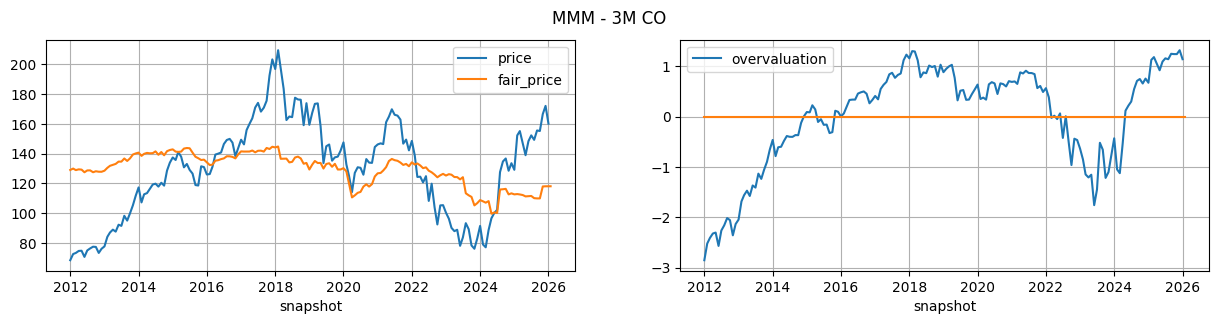

MMM fair_price = 1.344940 * (0.000263 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +157.296536


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000066740,2025-06-30,MMM,37.989,33.699,-1.002,0.000263,1.561579,1.34494,157.296536,-35.253713,109.882416
2025-11-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.000263,1.449647,1.34494,157.296536,-29.289556,117.903848
2025-12-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.000263,1.483345,1.34494,157.296536,-29.203931,118.019008
2026-01-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.000263,1.489826,1.34494,157.296536,-29.187463,118.041156
2026-01-24,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.000263,1.489826,1.34494,157.296536,-29.187463,118.041156


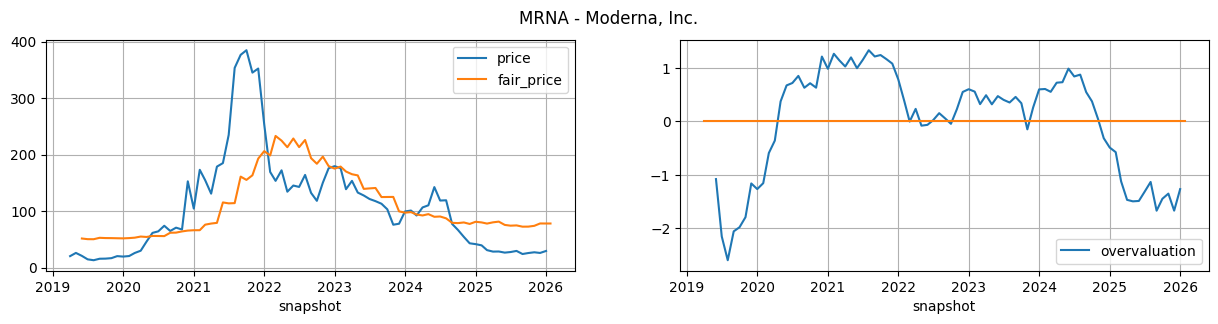

MRNA fair_price = 4.630207 * (0.980472 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +49.648761


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.980472,1.561579,4.630207,49.648761,4.952893,72.581683
2025-11-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.980472,1.449647,4.630207,49.648761,5.254772,73.979446
2025-12-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.980472,1.483345,4.630207,49.648761,6.158974,78.166091
2026-01-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.980472,1.489826,4.630207,49.648761,6.146155,78.106735
2026-01-24,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.980472,1.489826,4.630207,49.648761,6.146155,78.106735


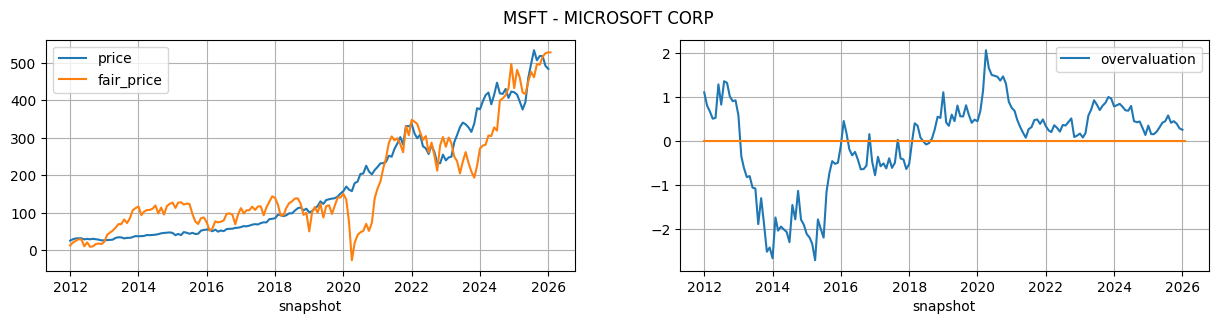

MSFT fair_price = 2.036584 * (0.430752 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +79.961257


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000789019,2025-06-30,MSFT,619.003,275.524,136.162,0.430752,1.561579,2.036584,79.961257,203.740654,494.896244
2025-11-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.430752,1.449647,2.036584,79.961257,213.989350,515.768577
2025-12-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.430752,1.483345,2.036584,79.961257,218.944160,525.859464
2026-01-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.430752,1.489826,2.036584,79.961257,219.897110,527.800226
2026-01-24,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.430752,1.489826,2.036584,79.961257,219.897110,527.800226


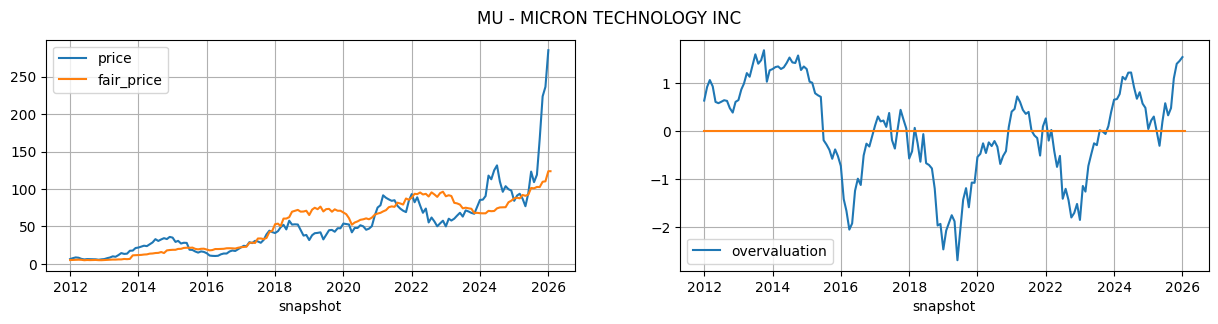

MU fair_price = 0.958858 * (1.517148 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -7.687380


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000723125,2025-05-29,MU,78.397,27.649,15.200,1.517148,1.561579,0.958858,-7.68738,115.026852,102.607094
2025-11-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.517148,1.449647,0.958858,-7.68738,122.388893,109.666250
2025-12-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.517148,1.483345,0.958858,-7.68738,122.979437,110.232498
2026-01-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.517148,1.489826,0.958858,-7.68738,137.072855,123.746092
2026-01-24,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.517148,1.489826,0.958858,-7.68738,137.072855,123.746092


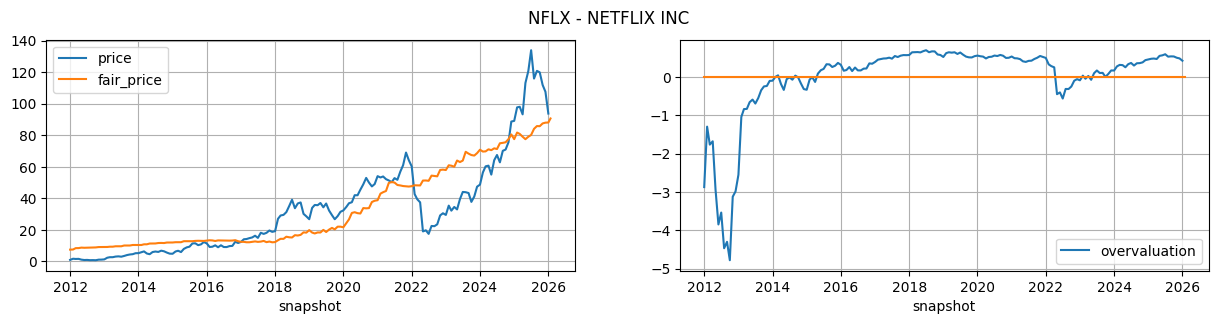

NFLX fair_price = 1.527711 * (1.236467 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +6.798939


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,1.236467,1.561579,1.527711,6.798939,51.672418,85.739436
2025-11-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.236467,1.449647,1.527711,6.798939,52.823970,87.498674
2025-12-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.236467,1.483345,1.527711,6.798939,53.146605,87.991567
2026-01-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.236467,1.489826,1.527711,6.798939,53.208657,88.086364
2026-01-24,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.236467,1.489826,1.527711,6.798939,54.882963,90.644218


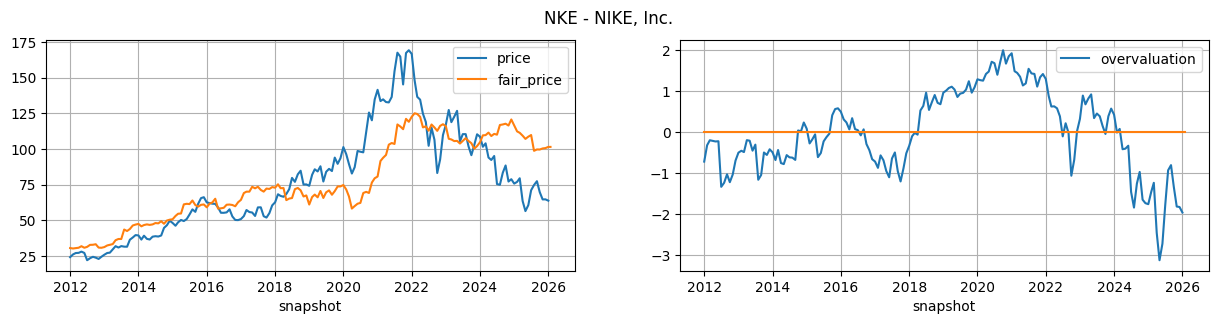

NKE fair_price = 2.077480 * (2.021858 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -17.512466


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320187,2025-05-31,NKE,36.579,23.366,3.698,2.021859,1.561579,2.07748,-17.512466,56.366288,99.587355
2025-11-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.021859,1.449647,2.07748,-17.512466,56.729529,100.341981
2025-12-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.021859,1.483345,2.07748,-17.512466,56.848346,100.588820
2026-01-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.021859,1.489826,2.07748,-17.512466,57.250881,101.425080
2026-01-24,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.021859,1.489826,2.07748,-17.512466,57.250881,101.425080


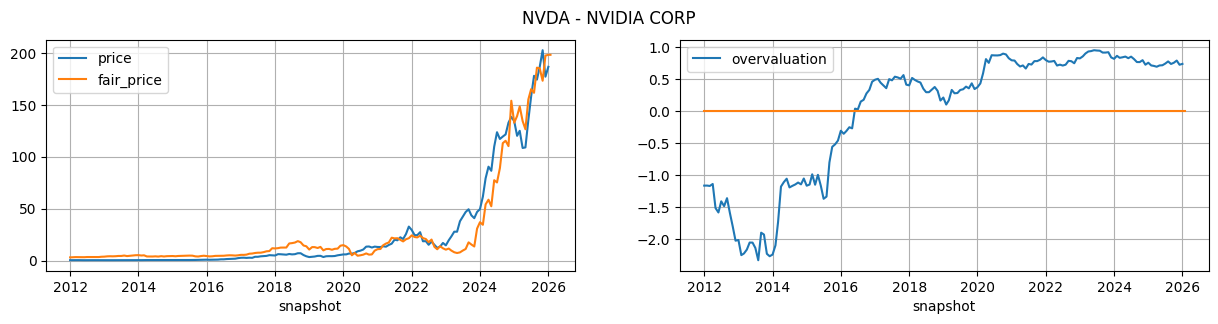

NVDA fair_price = 1.381985 * (0.367134 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +3.466451


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.367134,1.561579,1.381985,3.466451,131.357702,185.000884
2025-11-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.367134,1.449647,1.381985,3.466451,122.735063,173.084523
2025-12-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.367134,1.483345,1.381985,3.466451,140.265409,197.311206
2026-01-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.367134,1.489826,1.381985,3.466451,140.804357,198.056024
2026-01-24,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.367134,1.489826,1.381985,3.466451,140.804357,198.056024


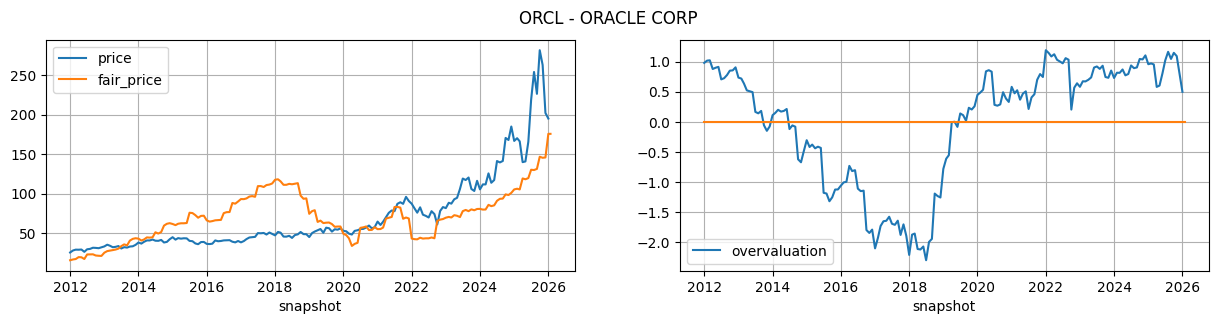

ORCL fair_price = 0.548367 * (2.930648 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -76.078807


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,2.930648,1.561579,0.548367,-76.078807,406.164556,146.648551
2025-11-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,2.930648,1.449647,0.548367,-76.078807,403.754225,145.326804
2025-12-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,2.930648,1.483345,0.548367,-76.078807,404.479861,145.724719
2026-01-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,2.930648,1.489826,0.548367,-76.078807,458.920119,175.577976
2026-01-24,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,2.930648,1.489826,0.548367,-76.078807,458.920119,175.577976


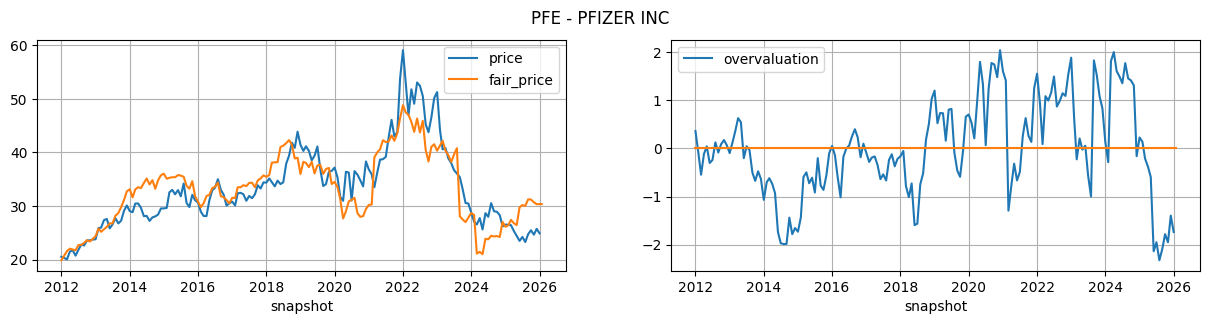

PFE fair_price = 0.308147 * (0.009938 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +59.448750


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.009938,1.561579,0.308147,59.44875,-91.634586,31.211848
2025-11-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.009938,1.449647,0.308147,59.44875,-93.334601,30.687994
2025-12-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.009938,1.483345,0.308147,59.44875,-94.457952,30.341837
2026-01-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.009938,1.489826,0.308147,59.44875,-94.373200,30.367953
2026-01-24,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.009938,1.489826,0.308147,59.44875,-94.373200,30.367953


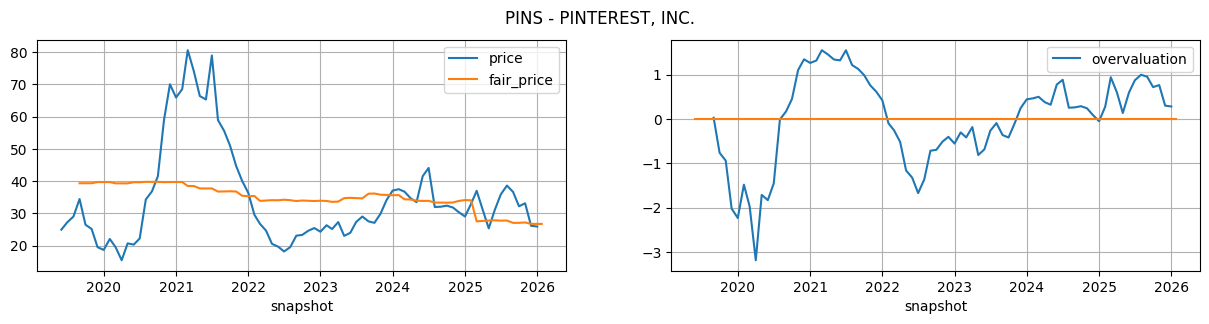

PINS fair_price = -1.033701 * (3.454197 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.448854


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,3.454196,1.561579,-1.033701,47.448854,19.748175,27.035143
2025-11-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,3.454196,1.449647,-1.033701,47.448854,19.628025,27.159342
2025-12-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.454196,1.483345,-1.033701,47.448854,20.062331,26.710399
2026-01-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.454196,1.489826,-1.033701,47.448854,20.069765,26.702715
2026-01-24,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.454196,1.489826,-1.033701,47.448854,20.069765,26.702715


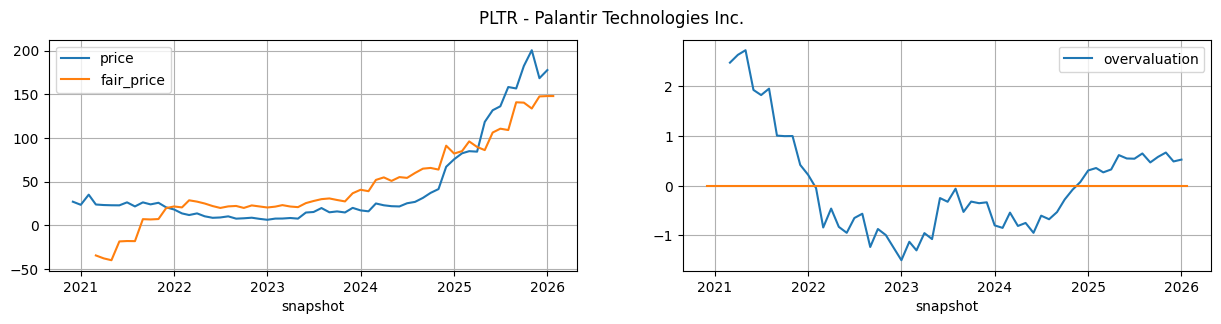

PLTR fair_price = 34.749668 * (0.396311 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -4.881189


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.396311,1.561579,34.749668,-4.881189,4.183241,140.485038
2025-11-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.396311,1.449647,34.749668,-4.881189,3.989643,133.757569
2025-12-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.396311,1.483345,34.749668,-4.881189,4.388132,147.604947
2026-01-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.396311,1.489826,34.749668,-4.881189,4.399911,148.014267
2026-01-24,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.396311,1.489826,34.749668,-4.881189,4.399911,148.014267


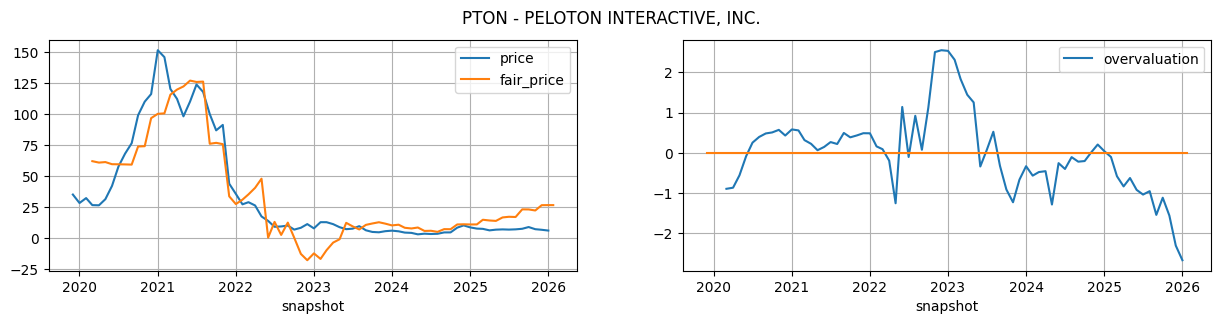

PTON fair_price = 22.784910 * (1.482821 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.585999


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.482821,1.561579,22.78491,-2.585999,1.132345,23.214385
2025-11-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.482821,1.449647,22.78491,-2.585999,1.095072,22.365119
2025-12-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.482821,1.483345,22.78491,-2.585999,1.282834,26.643265
2026-01-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.482821,1.489826,22.78491,-2.585999,1.285377,26.701210
2026-01-24,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.482821,1.489826,22.78491,-2.585999,1.285377,26.701210


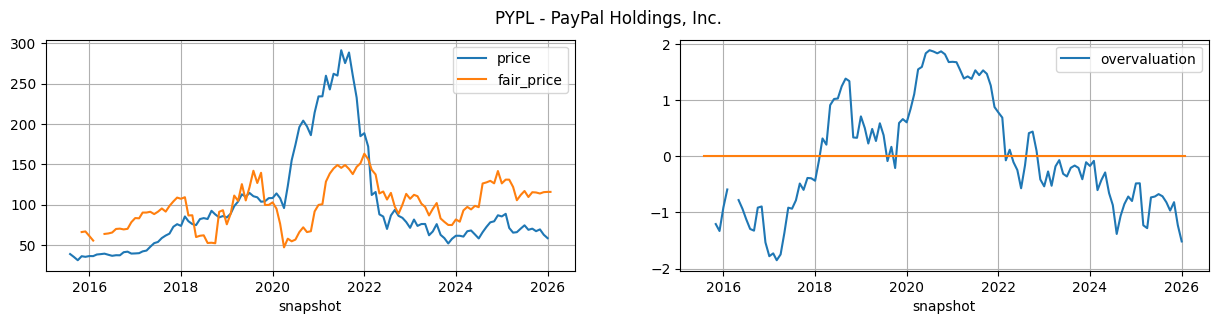

PYPL fair_price = 7.690890 * (0.858085 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -26.090073


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001633917,2025-06-30,PYPL,79.777,59.576,6.066,0.858085,1.561579,7.69089,-26.090073,18.351973,115.052932
2025-11-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.858085,1.449647,7.69089,-26.090073,18.188464,113.795402
2025-12-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.858085,1.483345,7.69089,-26.090073,18.405003,115.460776
2026-01-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.858085,1.489826,7.69089,-26.090073,18.446649,115.781074
2026-01-24,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.858085,1.489826,7.69089,-26.090073,18.446649,115.781074


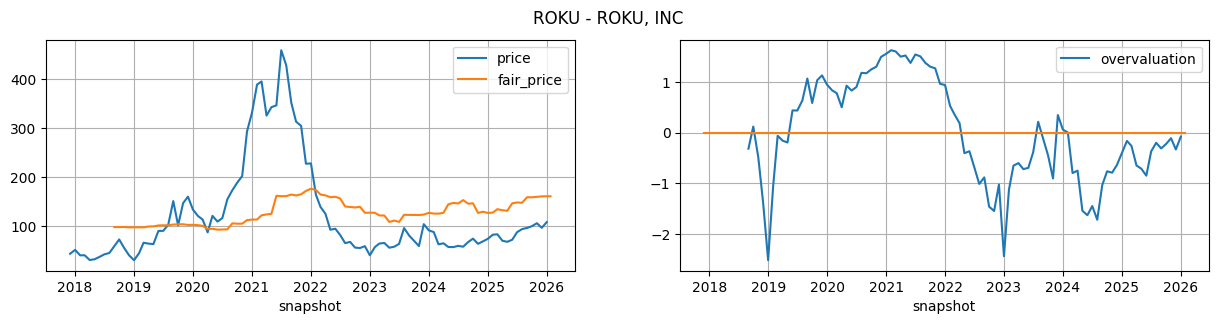

ROKU fair_price = 60.460156 * (0.486562 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +97.925986


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.486562,1.561579,60.460156,97.925986,1.011078,159.055895
2025-11-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.486562,1.449647,60.460156,97.925986,1.027466,160.046717
2025-12-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.486562,1.483345,60.460156,97.925986,1.042810,160.974441
2026-01-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.486562,1.489826,60.460156,97.925986,1.045761,161.152868
2026-01-24,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.486562,1.489826,60.460156,97.925986,1.045761,161.152868


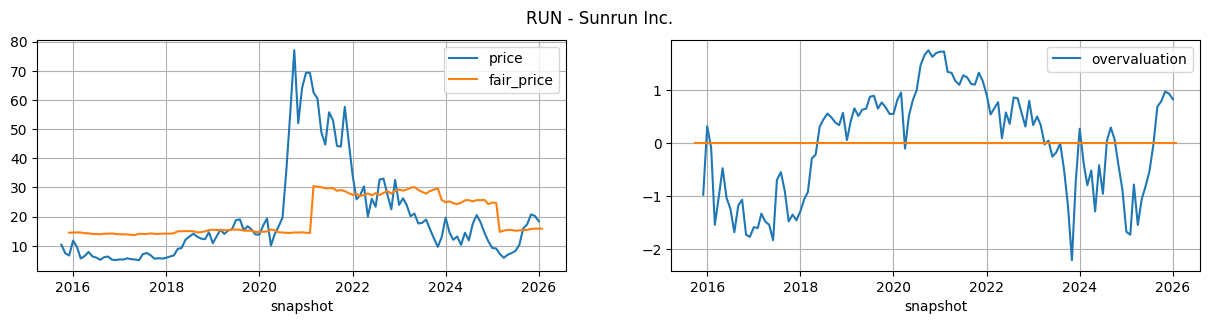

RUN fair_price = 3.559140 * (0.952707 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.102796


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.952707,1.561579,3.55914,13.102796,0.655665,15.436400
2025-11-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.952707,1.449647,3.55914,13.102796,0.746484,15.759637
2025-12-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.952707,1.483345,3.55914,13.102796,0.780618,15.881124
2026-01-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.952707,1.489826,3.55914,13.102796,0.775584,15.863207
2026-01-24,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.952707,1.489826,3.55914,13.102796,0.775584,15.863207


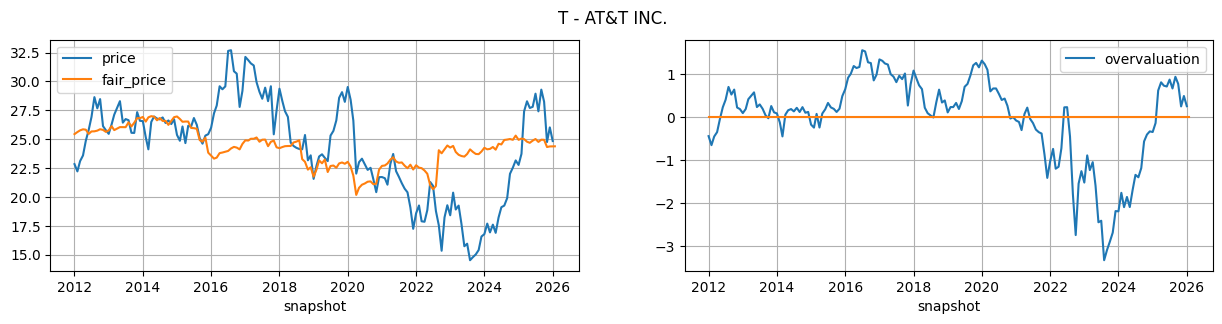

T fair_price = 0.036704 * (0.005689 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.939078


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732717,2025-06-30,T,405.491,284.097,40.943,0.005689,1.561579,0.036704,32.939078,-217.854436,24.942985
2025-11-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.005689,1.449647,0.036704,32.939078,-234.817745,24.320367
2025-12-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.005689,1.483345,0.036704,32.939078,-233.440876,24.370903
2026-01-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.005689,1.489826,0.036704,32.939078,-233.176065,24.380623
2026-01-24,0000732717,2025-09-30,T,423.213,296.458,40.860,0.005689,1.489826,0.036704,32.939078,-233.176065,24.380623


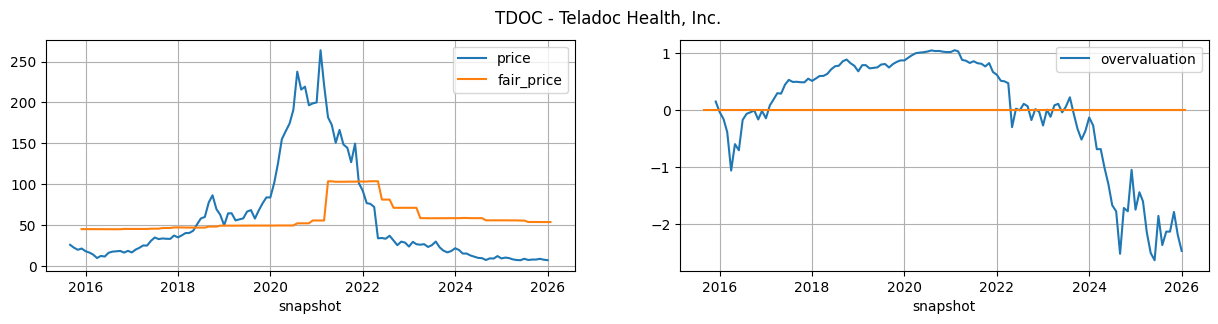

TDOC fair_price = 0.210255 * (15.997770 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +44.161378


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,15.997766,1.561579,0.210255,44.161378,45.299562,53.685841
2025-11-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,15.997766,1.449647,0.210255,44.161378,44.987937,53.620320
2025-12-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,15.997766,1.483345,0.210255,44.161378,44.997794,53.622393
2026-01-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,15.997766,1.489826,0.210255,44.161378,44.999690,53.622791
2026-01-24,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,15.997766,1.489826,0.210255,44.161378,44.999690,53.622791


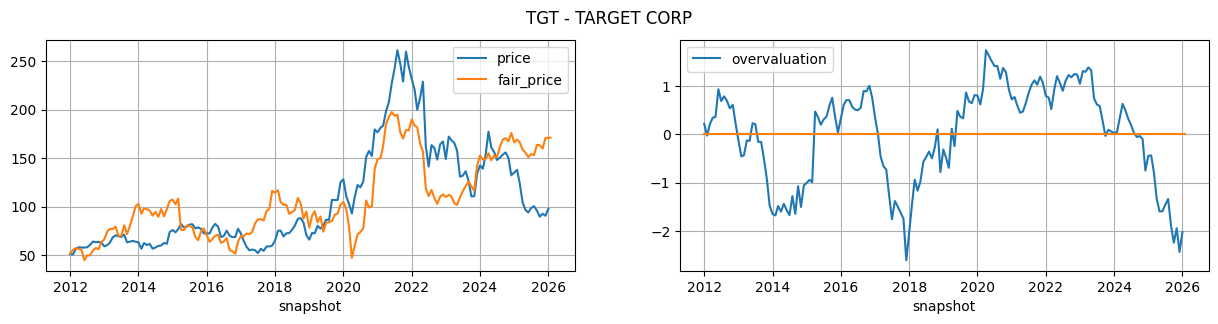

TGT fair_price = 5.077981 * (1.605373 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -143.400511


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.605373,1.561579,5.077981,-143.400511,60.413684,163.379042
2025-11-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.605373,1.449647,5.077981,-143.400511,59.698890,159.749330
2025-12-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.605373,1.483345,5.077981,-143.400511,61.866117,170.754467
2026-01-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.605373,1.489826,5.077981,-143.400511,61.910019,170.977400
2026-01-24,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.605373,1.489826,5.077981,-143.400511,61.910019,170.977400


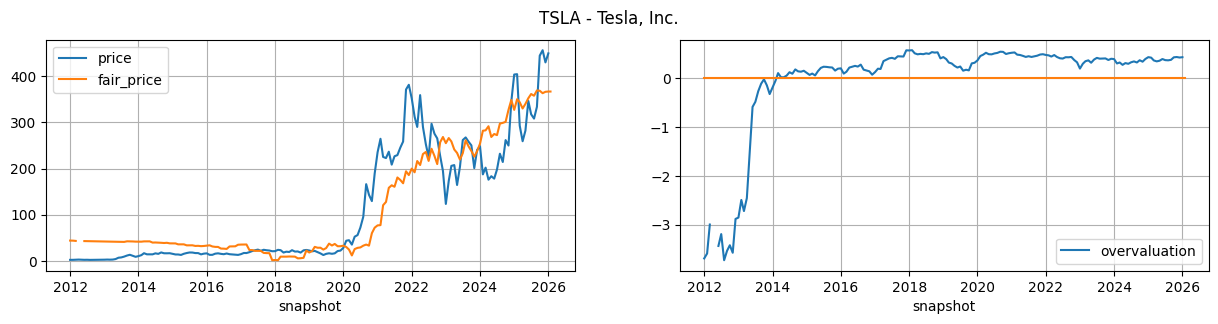

TSLA fair_price = 5.711550 * (0.651721 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +42.238707


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001318605,2025-06-30,TSLA,128.567,51.253,15.765,0.651721,1.561579,5.71155,42.238707,57.155151,368.683207
2025-11-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.651721,1.449647,5.71155,42.238707,56.222004,363.353490
2025-12-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.651721,1.483345,5.71155,42.238707,56.752668,366.384405
2026-01-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.651721,1.489826,5.71155,42.238707,56.854730,366.967336
2026-01-24,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.651721,1.489826,5.71155,42.238707,56.854730,366.967336


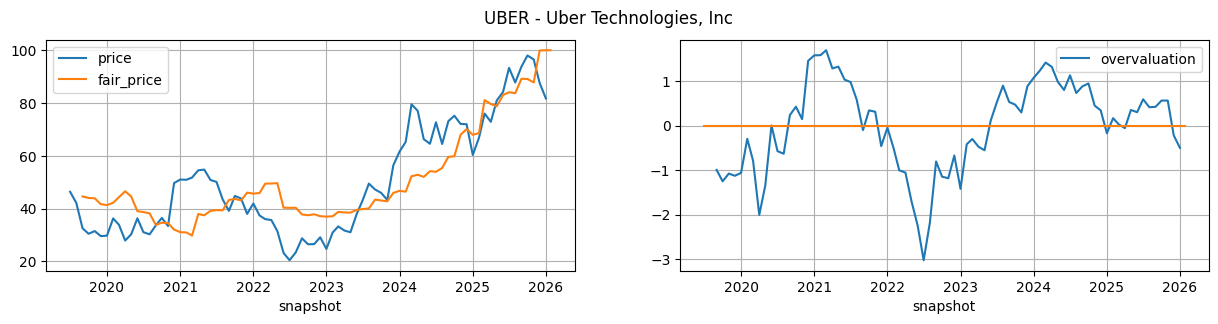

UBER fair_price = 1.336530 * (1.403964 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +10.314494


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.403964,1.561579,1.33653,10.314494,58.937418,89.086127
2025-11-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.403964,1.449647,1.33653,10.314494,57.953653,87.771295
2025-12-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.403964,1.483345,1.33653,10.314494,67.022352,99.891884
2026-01-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.403964,1.489826,1.33653,10.314494,67.080460,99.969547
2026-01-24,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.403964,1.489826,1.33653,10.314494,67.080460,99.969547


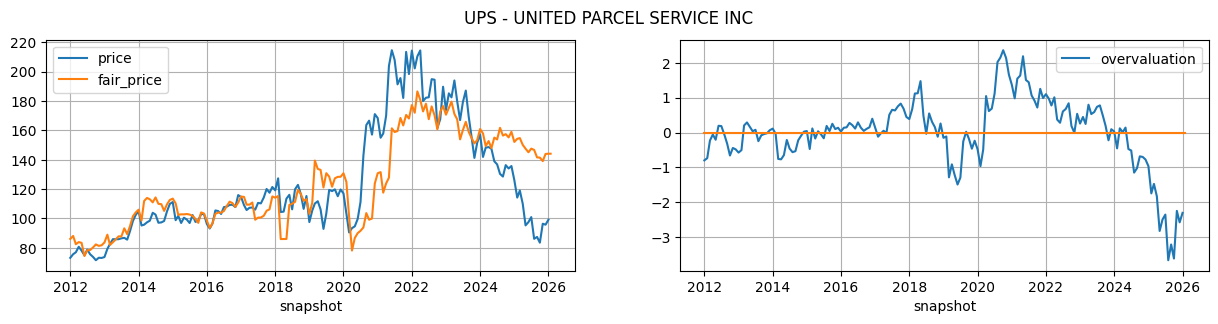

UPS fair_price = 2.870395 * (0.822178 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +98.943908


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.822178,1.561579,2.870395,98.943908,14.817388,141.475658
2025-11-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.822178,1.449647,2.870395,98.943908,13.980252,139.072749
2025-12-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.822178,1.483345,2.870395,98.943908,15.681487,143.955963
2026-01-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.822178,1.489826,2.870395,98.943908,15.736335,144.113399
2026-01-24,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.822178,1.489826,2.870395,98.943908,15.736335,144.113399


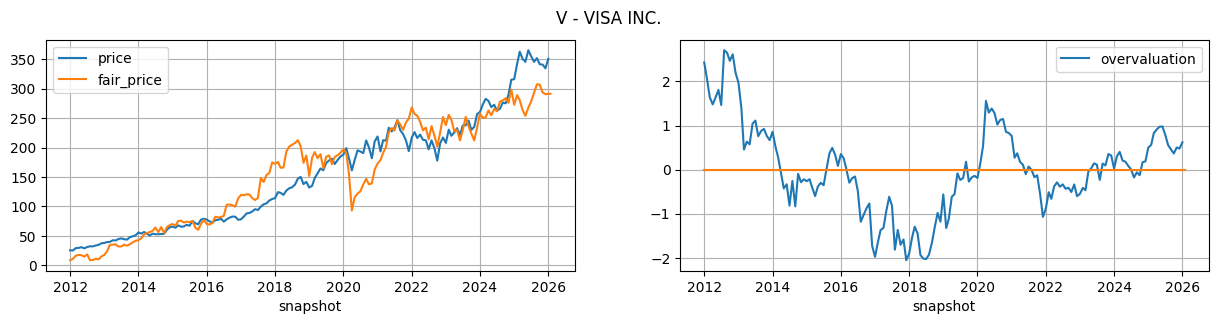

V fair_price = 4.981814 * (1.099604 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -118.292210


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.099604,1.561579,4.981814,-118.29221,85.300459,306.658834
2025-11-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.099604,1.449647,4.981814,-118.29221,82.671749,293.563089
2025-12-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.099604,1.483345,4.981814,-118.29221,82.036682,290.399300
2026-01-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.099604,1.489826,4.981814,-118.29221,82.186126,291.143801
2026-01-24,0001403161,2025-09-30,V,99.627,61.718,23.059,1.099604,1.489826,4.981814,-118.29221,82.186126,291.143801


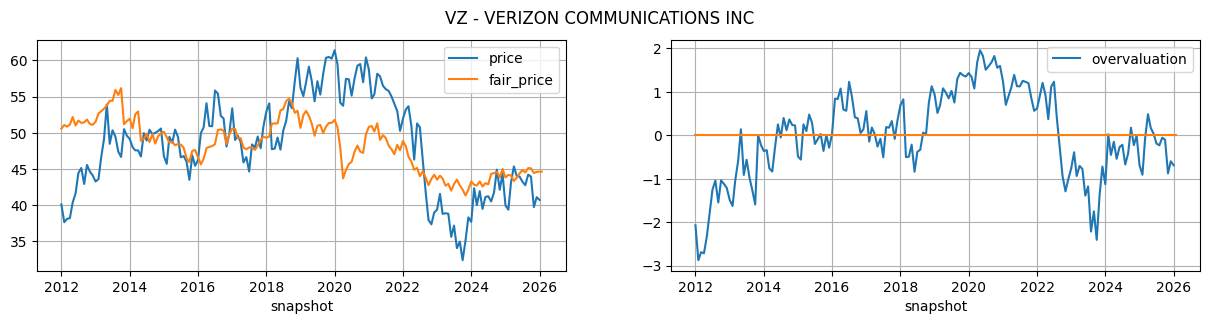

VZ fair_price = 0.127616 * (0.023368 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +72.156986


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,0.023368,1.561579,0.127616,72.156986,-212.033008,45.098282
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.023368,1.449647,0.127616,72.156986,-217.165480,44.443299
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.023368,1.483345,0.127616,72.156986,-215.869652,44.608667
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.023368,1.489826,0.127616,72.156986,-215.620428,44.640471
2026-01-24,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.023368,1.489826,0.127616,72.156986,-215.620428,44.640471


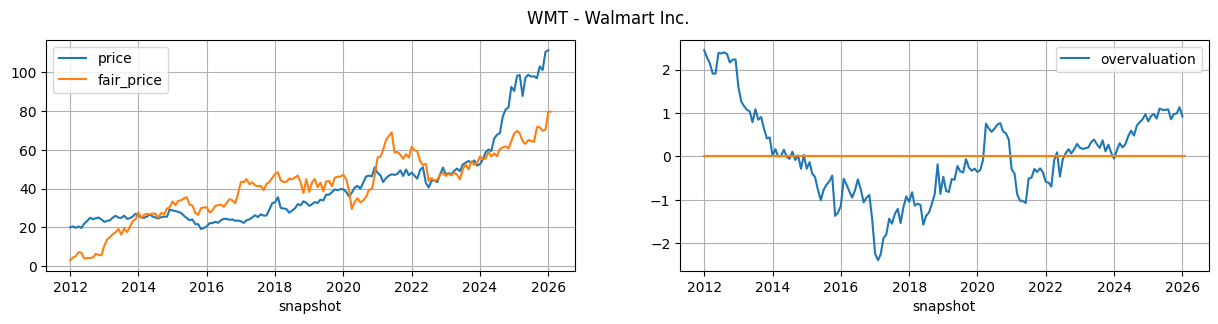

WMT fair_price = 0.426959 * (1.663031 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -69.140598


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.663031,1.561579,0.426959,-69.140598,329.707194,71.630733
2025-11-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.663031,1.449647,0.426959,-69.140598,325.404773,69.793777
2025-12-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.663031,1.483345,0.426959,-69.140598,326.700028,70.346798
2026-01-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.663031,1.489826,0.426959,-69.140598,348.529689,79.667160
2026-01-24,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.663031,1.489826,0.426959,-69.140598,348.529689,79.667160


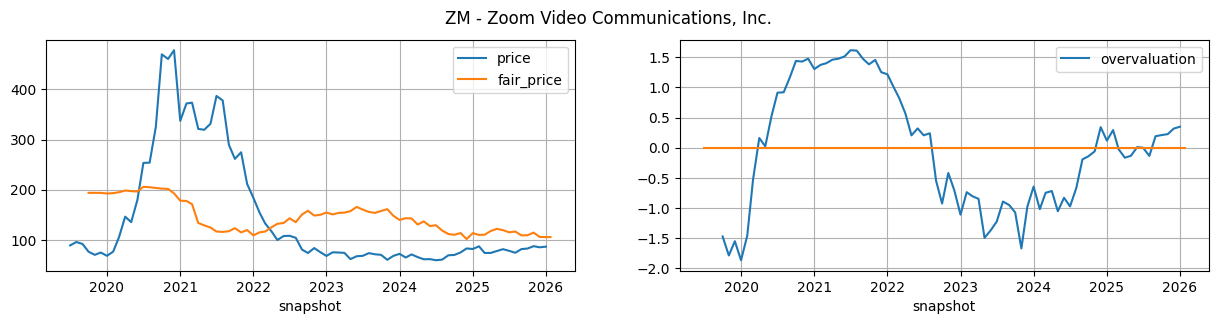

ZM fair_price = -24.360287 * (0.236871 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +194.556762


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.236871,1.561579,-24.360287,194.556762,3.509306,109.069065
2025-11-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.236871,1.449647,-24.360287,194.556762,3.295183,114.285164
2025-12-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.236871,1.483345,-24.360287,194.556762,3.648525,105.677657
2026-01-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.236871,1.489826,-24.360287,194.556762,3.661869,105.352573
2026-01-24,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.236871,1.489826,-24.360287,194.556762,3.661869,105.352573


In [17]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    # The asset and cash multipliers are not available for the most recent snapshots,
    # which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['asmul'] = df['asmul'].interpolate()
    df['cashmul'] = df['cashmul'].interpolate()
    df['fair_model'] = df['asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']
    df['fair_price'] = df['fair_model'] * df['slope'] + df['intercept']
    df['overvaluation'] = -1 * preprocessing.scale(df['fair_price']/df['price'])

    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(f"{ticker} - {name}")
    fig.set_size_inches(15,5)
    df[['price','fair_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{} fair_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, df['slope'].mean(), df['asmul'].mean(),
        "+" if df['intercept'].mean() >= 0 else "", df['intercept'].mean()
    ))

    # Display a few most recent records from the resultset
    df = df.reset_index().set_index(['snapshot','cik'])
    display(df.tail(5).dropna(axis='columns'))

    return df

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

In [18]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

               price  fair_price
price       1.000000    0.916552
fair_price  0.916552    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,40.12,0.023368,-1.141094,-169.148568,0.127616,72.156986,-169.148568,50.571002,-2.071106
2012-02-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,37.66,0.023368,-1.007566,-165.174620,0.127616,72.156986,-165.174620,51.078140,-2.875800
2012-03-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.11,0.023368,-0.933211,-166.958714,0.127616,72.156986,-166.958714,50.850462,-2.691102
2012-04-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.23,0.023368,-0.862020,-164.838644,0.127616,72.156986,-164.838644,51.121016,-2.715366
2012-05-01,0000732712,2012-03-31,VZ,222.921,134.500,30.702,40.38,0.023368,-0.888194,-156.560212,0.127616,72.156986,-156.560212,52.177472,-2.337097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,43.95,0.023368,1.561579,-212.033008,0.127616,72.156986,-212.033008,45.098282,-0.102557
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,39.74,0.023368,1.449647,-217.165480,0.127616,72.156986,-217.165480,44.443299,-0.877194
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,41.11,0.023368,1.483345,-215.869652,0.127616,72.156986,-215.869652,44.608667,-0.597939


All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

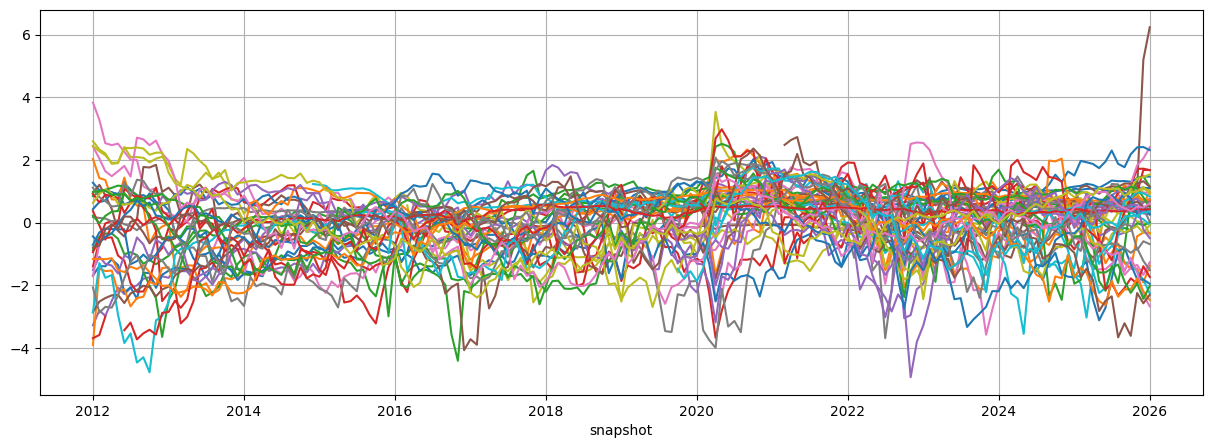

In [19]:
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='overvaluation').plot(
    grid=True, legend=False, figsize=(15,5))
plt.show()

In [20]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.